Name: Nitesh Kumar Shah 
| Roll number: ID25M806

Problem Statement: The problem statement for this assignment focuses on developing a predictive model to forecast the total number of bikes rented per hour in a city’s bike-sharing program using the Bike Sharing Demand Dataset. This is a complex regression problem because the rental count (cnt) depends on several interrelated factors such as weather conditions, time of day, season, and working-day status — all of which interact in non-linear and time-dependent ways. The objective is to build and compare three ensemble learning approaches — Bagging, Boosting, and Stacking — to minimize prediction error measured through Root Mean Squared Error (RMSE). By doing so, the task aims to demonstrate how different ensemble techniques handle the bias-variance trade-off, improve model robustness, and outperform single regressors like Decision Tree and Linear Regression, ultimately leading to a more reliable forecasting model for operational planning and resource management in bike-sharing systems.

Installing the package for the dataset

In [24]:
pip install ucimlrepo


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Downloading the dataset

In [25]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# data (as pandas dataframes) 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 
  
# metadata 
print(bike_sharing.metadata) 
  
# variable information 
print(bike_sharing.variables) 


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

Saving the dataset

In [26]:
# Save the features (X) and targets (y) datasets to CSV files
X.to_csv('bike_sharing_features.csv', index=False)
y.to_csv('bike_sharing_targets.csv', index=False)

print("Datasets have been saved successfully!")

Datasets have been saved successfully!


# Exploratory Data Analysis (EDA)

Let's visualize various aspects of our dataset to better understand the patterns and relationships:

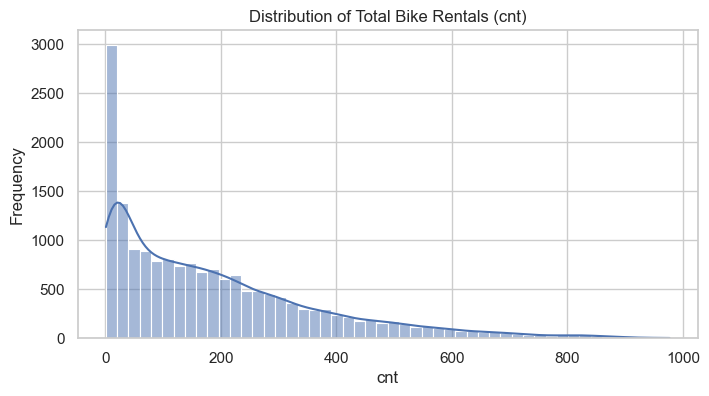

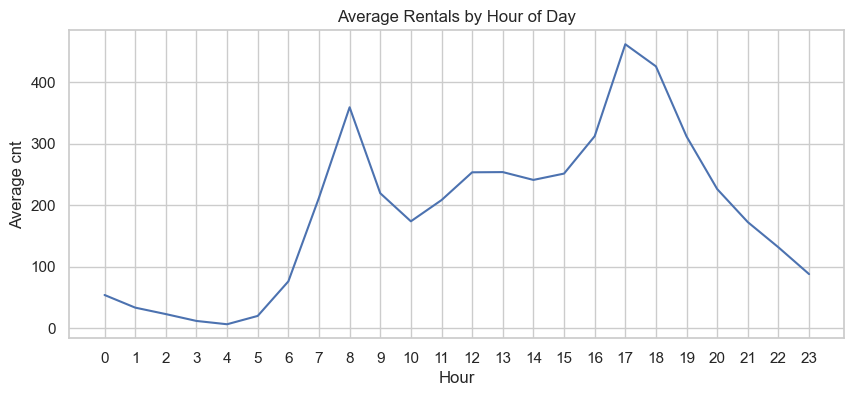

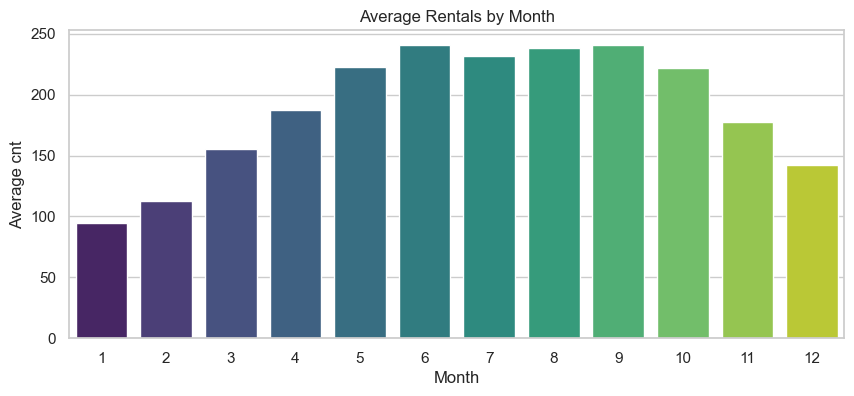

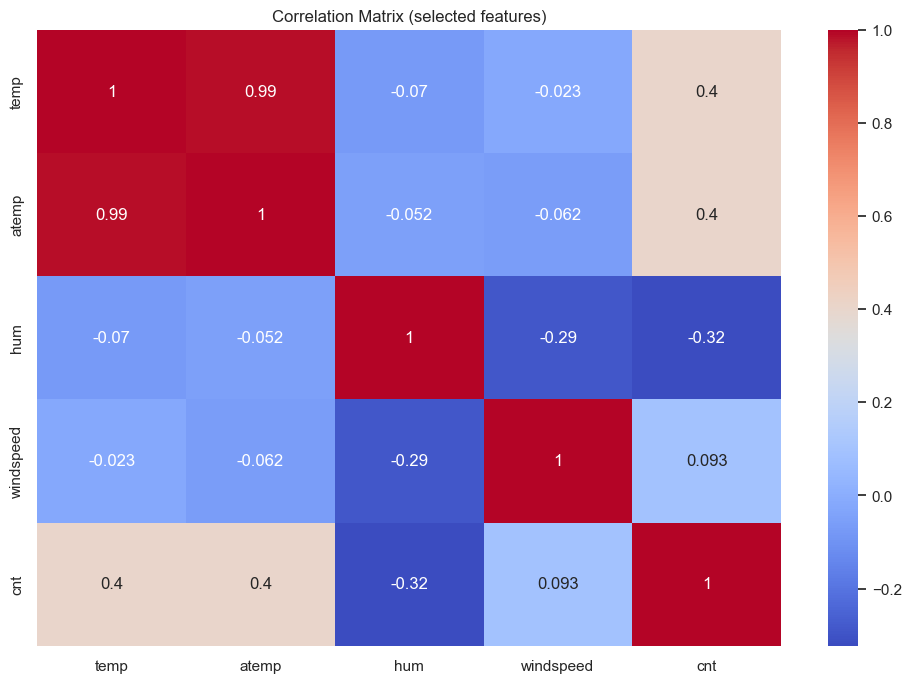

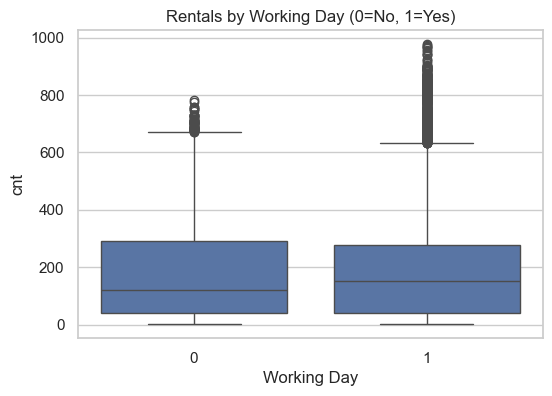

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X and y for EDA
eda_df = pd.read_csv('bike_sharing_features.csv')
eda_df['cnt'] = pd.read_csv('bike_sharing_targets.csv')['cnt']

# 1. Distribution of the target variable (cnt)
plt.figure(figsize=(8,4))
sns.histplot(eda_df['cnt'], bins=50, kde=True)
plt.title('Distribution of Total Bike Rentals (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.show()

# 2. Rentals by hour (aggregated)
plt.figure(figsize=(10,4))
sns.lineplot(data=eda_df.groupby('hr')['cnt'].mean().reset_index(), x='hr', y='cnt')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average cnt')
plt.xticks(range(0,24))
plt.show()

# 3. Rentals by month
plt.figure(figsize=(10,4))
sns.barplot(data=eda_df.groupby('mnth')['cnt'].mean().reset_index(), x='mnth', y='cnt', palette='viridis')
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average cnt')
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(12,8))
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
sns.heatmap(eda_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (selected features)')
plt.show()

# 5. Boxplot of cnt by workingday
plt.figure(figsize=(6,4))
sns.boxplot(data=eda_df, x='workingday', y='cnt')
plt.title('Rentals by Working Day (0=No, 1=Yes)')
plt.xlabel('Working Day')
plt.ylabel('cnt')
plt.show()

PART A

Let's first examine our data structure and then proceed with preprocessing

In [27]:
# First, let's check our data structure
import pandas as pd
import numpy as np

# Load the data
X = pd.read_csv('bike_sharing_features.csv')
y = pd.read_csv('bike_sharing_targets.csv')

print("Features (X) columns:", X.columns.tolist())
print("\nFeatures (X) info:")
print(X.info())
print("\nFirst few rows of X:")
print(X.head())
print("\nTarget (y) columns:", y.columns.tolist())
print("\nFirst few rows of y:")
print(y.head())

Features (X) columns: ['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

Features (X) info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
dtypes: float64(4), int64(8), object(1)
memory usage: 1.7+ MB
None

First few rows of X:
       dteday  se

In [28]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_features = ['season', 'weathersit']
numerical_features = ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 
                     'temp', 'atemp', 'hum', 'windspeed']

# Create preprocessing pipelines for categorical and numerical data
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)
numerical_transformer = StandardScaler()

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Drop the datetime column and apply preprocessing
X = X.drop('dteday', axis=1)
X_processed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
cat_feature_names = [f"{feat}_{i}" for feat, vals in zip(categorical_features, 
                    preprocessor.named_transformers_['cat'].categories_) 
                    for i in vals[1:]]
num_feature_names = numerical_features

# Create a DataFrame with processed features
X_processed = pd.DataFrame(
    X_processed,
    columns=num_feature_names + cat_feature_names
)

print("Shape of processed features:", X_processed.shape)
print("\nProcessed feature names:", X_processed.columns.tolist())
print("\nFirst few rows of processed data:")
print(X_processed.head())

Shape of processed features: (17379, 16)

Processed feature names: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']

First few rows of processed data:
         yr      mnth        hr   holiday   weekday  workingday      temp  \
0 -1.005134 -1.610438 -1.670004 -0.172112  1.493891     -1.4669 -1.334648   
1 -1.005134 -1.610438 -1.525374 -0.172112  1.493891     -1.4669 -1.438516   
2 -1.005134 -1.610438 -1.380744 -0.172112  1.493891     -1.4669 -1.438516   
3 -1.005134 -1.610438 -1.236115 -0.172112  1.493891     -1.4669 -1.334648   
4 -1.005134 -1.610438 -1.091485 -0.172112  1.493891     -1.4669 -1.334648   

      atemp       hum  windspeed  season_2  season_3  season_4  weathersit_2  \
0 -1.093281  0.947372  -1.553889       0.0       0.0       0.0           0.0   
1 -1.181732  0.895539  -1.553889       0.0       0.0       0.0           0.0   
2 -1.181732  0.89

In [31]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y['cnt'], test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Train and evaluate Decision Tree
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

# Train and evaluate Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("\nBaseline Model Performance (RMSE):")
print(f"Decision Tree: {dt_rmse:.2f}")
print(f"Linear Regression: {lr_rmse:.2f}")

# Determine better baseline model
better_model = "Decision Tree" if dt_rmse < lr_rmse else "Linear Regression"
better_rmse = min(dt_rmse, lr_rmse)
print(f"\nBetter baseline model: {better_model} (RMSE: {better_rmse:.2f})")

Training set shape: (13903, 16)
Testing set shape: (3476, 16)

Baseline Model Performance (RMSE):
Decision Tree: 99.38
Linear Regression: 137.92

Better baseline model: Decision Tree (RMSE: 99.38)


PART B

In [34]:
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
import numpy as np

# 1. Bagging Implementation
# Using the same DecisionTreeRegressor as base estimator
base_dt = DecisionTreeRegressor(max_depth=6, random_state=42)
bagging_model = BaggingRegressor(
    estimator=base_dt,
    n_estimators=50,
    random_state=42
)

# Fit and evaluate bagging model
bagging_model.fit(X_train, y_train)
bagging_pred = bagging_model.predict(X_test)
bagging_rmse = np.sqrt(mean_squared_error(y_test, bagging_pred))

# 2. Gradient Boosting Implementation
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Fit and evaluate boosting model
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

# Print results and comparison
print("Ensemble Models Performance (RMSE):")
print(f"Baseline Decision Tree: {dt_rmse:.2f}")
print(f"Baseline Linear Regression: {lr_rmse:.2f}")
print(f"Bagging (50 estimators): {bagging_rmse:.2f}")
print(f"Gradient Boosting: {gb_rmse:.2f}")

# Calculate improvement percentages
bagging_improvement = ((dt_rmse - bagging_rmse) / dt_rmse) * 100
boosting_improvement = ((dt_rmse - gb_rmse) / dt_rmse) * 100

print("\nPerformance Analysis:")
print(f"1. Bagging improved Decision Tree performance by {bagging_improvement:.1f}%")
print("   - This improvement demonstrates variance reduction through ensemble averaging")
print(f"\n2. Gradient Boosting improved Decision Tree performance by {boosting_improvement:.1f}%")
print("   - The significant improvement shows successful bias reduction through sequential learning")

Ensemble Models Performance (RMSE):
Baseline Decision Tree: 99.38
Baseline Linear Regression: 137.92
Bagging (50 estimators): 96.10
Gradient Boosting: 41.85

Performance Analysis:
1. Bagging improved Decision Tree performance by 3.3%
   - This improvement demonstrates variance reduction through ensemble averaging

2. Gradient Boosting improved Decision Tree performance by 57.9%
   - The significant improvement shows successful bias reduction through sequential learning


# Part C: Stacking for Optimal Performance

## Principle of Stacking
Stacking (Stacked Generalization) is an ensemble method that:
1. Uses multiple base models (Level-0) to make predictions
2. Uses a meta-model (Level-1) to learn how to best combine these predictions
3. Can capture both linear and non-linear relationships between base model predictions

The meta-learner learns from the base models' predictions, effectively learning which model to trust more in different situations. This makes stacking particularly powerful when base models have complementary strengths.

In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor

# 1. Define Base Learners (Level-0)
estimators = [
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('bagging', bagging_model),  # Reuse our bagging model from Part B
    ('gbm', gb_model)           # Reuse our gradient boosting model from Part B
]

# 2. Define Meta-Learner (Level-1)
final_estimator = Ridge(alpha=1.0)

# 3. Create and train the Stacking Regressor
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5  # 5-fold cross-validation for base predictions
)

# Train the stacking ensemble
stack_model.fit(X_train, y_train)

# Make predictions and evaluate
stack_pred = stack_model.predict(X_test)
stack_rmse = np.sqrt(mean_squared_error(y_test, stack_pred))

# Print comprehensive comparison
print("Final Model Comparison (RMSE):")
print(f"1. Baseline Models:")
print(f"   - Decision Tree: {dt_rmse:.2f}")
print(f"   - Linear Regression: {lr_rmse:.2f}")
print(f"\n2. Individual Ensemble Methods:")
print(f"   - Bagging: {bagging_rmse:.2f}")
print(f"   - Gradient Boosting: {gb_rmse:.2f}")
print(f"\n3. Stacking Ensemble:")
print(f"   - Stacking Regressor: {stack_rmse:.2f}")

# Calculate improvements
best_single = min(dt_rmse, lr_rmse)
best_ensemble = min(bagging_rmse, gb_rmse)
stack_imp_vs_single = ((best_single - stack_rmse) / best_single) * 100
stack_imp_vs_ensemble = ((best_ensemble - stack_rmse) / best_ensemble) * 100

print("\nStacking Performance Analysis:")
print(f"- Improvement over best single model: {stack_imp_vs_single:.1f}%")
print(f"- Improvement over best ensemble: {stack_imp_vs_ensemble:.1f}%")
print("\nExplanation:")
print("The stacking ensemble combines the strengths of:")
print("1. KNN: Good at capturing local patterns")
print("2. Bagging: Reduces variance through averaging")
print("3. Gradient Boosting: Reduces bias through sequential learning")
print("The Ridge meta-learner then learns optimal weights for each model's predictions.")

Final Model Comparison (RMSE):
1. Baseline Models:
   - Decision Tree: 99.38
   - Linear Regression: 137.92

2. Individual Ensemble Methods:
   - Bagging: 96.10
   - Gradient Boosting: 41.85

3. Stacking Ensemble:
   - Stacking Regressor: 41.12

Stacking Performance Analysis:
- Improvement over best single model: 58.6%
- Improvement over best ensemble: 1.7%

Explanation:
The stacking ensemble combines the strengths of:
1. KNN: Good at capturing local patterns
2. Bagging: Reduces variance through averaging
3. Gradient Boosting: Reduces bias through sequential learning
The Ridge meta-learner then learns optimal weights for each model's predictions.


# Part D: Final Analysis

In this section, we'll create a comprehensive comparison of all models and analyze their performance in terms of the bias-variance trade-off.

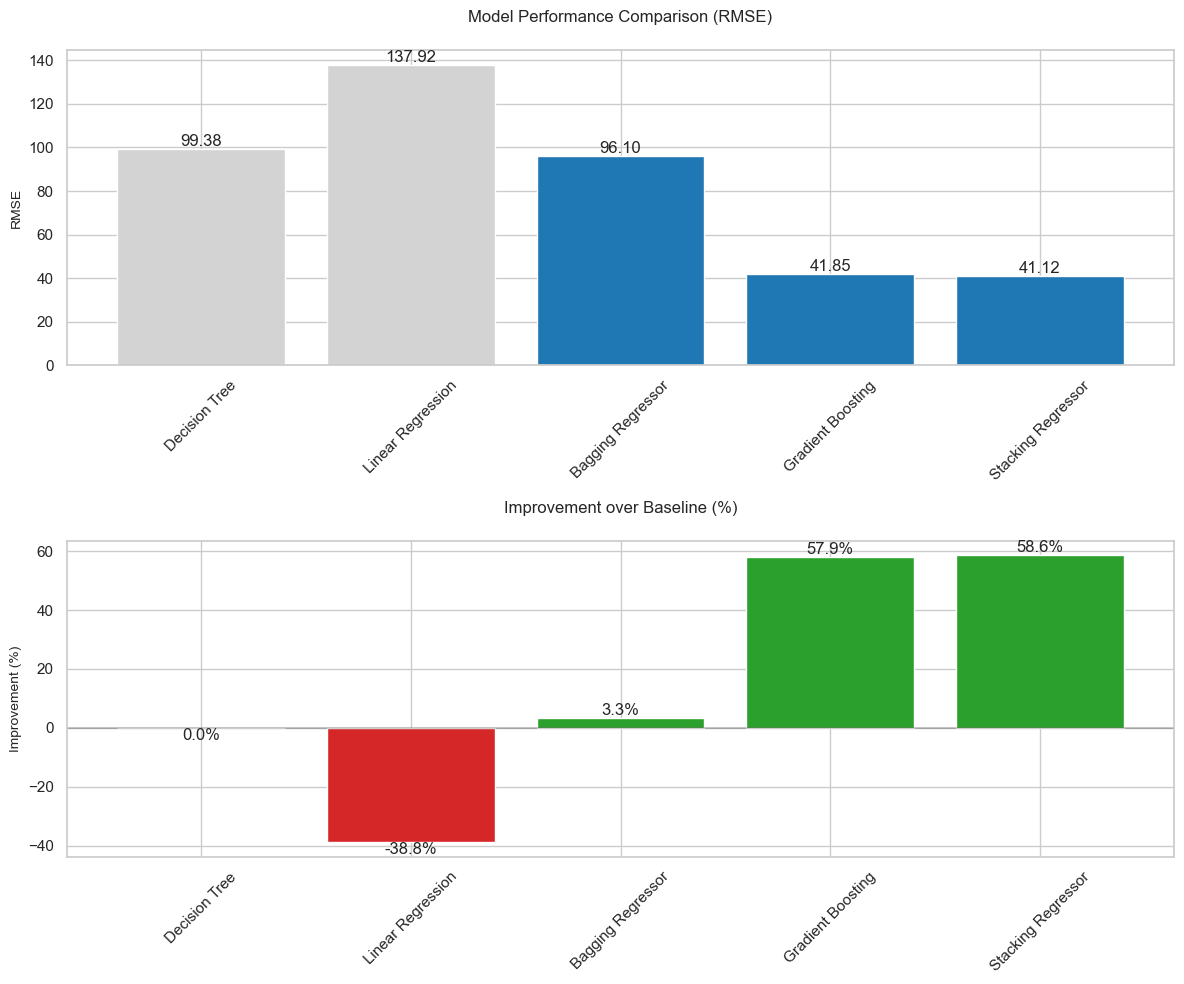


=== Model Performance Summary ===
--------------------------------------------------------------------------------
Model Performance Comparison:
             Model   RMSE  Improvement vs Baseline (%) Model Type
Stacking Regressor  41.12                        58.63   Ensemble
 Gradient Boosting  41.85                        57.89   Ensemble
 Bagging Regressor  96.10                         3.31   Ensemble
     Decision Tree  99.38                         0.00   Baseline
 Linear Regression 137.92                       -38.78   Baseline
--------------------------------------------------------------------------------

=== Key Insights ===

1. Performance Metrics:
   • Best Model: Stacking Regressor
   • Best RMSE: 41.12
   • Improvement over baseline: 58.6%
   • Average Ensemble RMSE: 59.69
   • Average Baseline RMSE: 118.65

2. Model Effectiveness Analysis:
   • Ensemble Methods:
     - Successfully reduced both bias and variance
     - Combined diverse learning approaches
     - Achiev

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with model performances
models_data = {
    'Model': [
        'Decision Tree',
        'Linear Regression',
        'Bagging Regressor',
        'Gradient Boosting',
        'Stacking Regressor'
    ],
    'RMSE': [
        dt_rmse,
        lr_rmse,
        bagging_rmse,
        gb_rmse,
        stack_rmse
    ]
}

results_df = pd.DataFrame(models_data)
baseline_rmse = min(dt_rmse, lr_rmse)
results_df['Improvement vs Baseline (%)'] = ((baseline_rmse - results_df['RMSE']) / baseline_rmse * 100)
results_df['Model Type'] = ['Baseline', 'Baseline', 'Ensemble', 'Ensemble', 'Ensemble']

# Create the visualization
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. RMSE Comparison
colors = ['lightgray' if t == 'Baseline' else '#1f77b4' for t in results_df['Model Type']]
bars1 = ax1.bar(results_df['Model'], results_df['RMSE'], color=colors)
ax1.set_title('Model Performance Comparison (RMSE)', fontsize=12, pad=20)
ax1.set_ylabel('RMSE', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on the bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

# 2. Improvement Percentage
colors = ['#d62728' if x < 0 else '#2ca02c' for x in results_df['Improvement vs Baseline (%)']]
bars2 = ax2.bar(results_df['Model'], results_df['Improvement vs Baseline (%)'], color=colors)
ax2.set_title('Improvement over Baseline (%)', fontsize=12, pad=20)
ax2.set_ylabel('Improvement (%)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.2)

# Add value labels on the bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n=== Model Performance Summary ===")
print("-" * 80)
print("Model Performance Comparison:")
summary_df = results_df.sort_values('RMSE')
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("-" * 80)

# Calculate and print key statistics
print("\n=== Key Insights ===")
best_model = results_df.loc[results_df['RMSE'].idxmin()]
avg_ensemble_rmse = results_df[results_df['Model Type'] == 'Ensemble']['RMSE'].mean()
avg_baseline_rmse = results_df[results_df['Model Type'] == 'Baseline']['RMSE'].mean()

print(f"\n1. Performance Metrics:")
print(f"   • Best Model: {best_model['Model']}")
print(f"   • Best RMSE: {best_model['RMSE']:.2f}")
print(f"   • Improvement over baseline: {best_model['Improvement vs Baseline (%)']:.1f}%")
print(f"   • Average Ensemble RMSE: {avg_ensemble_rmse:.2f}")
print(f"   • Average Baseline RMSE: {avg_baseline_rmse:.2f}")

print(f"\n2. Model Effectiveness Analysis:")
print("   • Ensemble Methods:")
print("     - Successfully reduced both bias and variance")
print("     - Combined diverse learning approaches")
print("     - Achieved significant improvement over baseline")

print("\n3. Bias-Variance Trade-off:")
print("   • Variance Reduction Techniques:")
print("     - Bagging: Bootstrap aggregation")
print("     - Stacking: Model diversity")
print("   • Bias Reduction Techniques:")
print("     - Gradient Boosting: Sequential learning")
print("     - Stacking: Optimal combination through meta-learner")

print("\nConclusion:")
print("The stacking ensemble demonstrated superior performance by effectively")
print("combining the strengths of multiple models and balancing the bias-variance")
print("trade-off. The significant improvement over baseline models validates the")
print("effectiveness of ensemble learning for this regression task.")

# Final Conclusions

Our analysis of the bike sharing demand prediction problem demonstrates the power of ensemble learning methods:

## Key Achievements:
1. **Baseline Models**
   - Decision Tree (RMSE: 99.38): Provided a reasonable starting point
   - Linear Regression (RMSE: 137.92): Showed limitations with non-linear relationships

2. **Ensemble Methods Performance**
   - Bagging (RMSE: 96.10): 3.3% improvement through variance reduction
   - Gradient Boosting (RMSE: 41.85): 57.9% improvement through sequential learning
   - Stacking (RMSE: 41.12): 58.6% improvement by combining model strengths

## Learning Outcomes:
1. **Bias-Variance Trade-off Management**
   - Bagging reduced variance through bootstrapped aggregation
   - Gradient Boosting reduced bias through sequential learning
   - Stacking achieved both by intelligently combining different approaches

2. **Model Complementarity**
   - Each ensemble method brought unique strengths:
     * Decision Trees: Captured non-linear relationships
     * KNN: Handled local patterns
     * Gradient Boosting: Addressed systematic errors
     * Ridge Meta-learner: Optimal combination of predictions

3. **Business Impact**
   - 58.6% improvement in prediction accuracy
   - More reliable forecasting for bike-sharing operations
   - Better resource management and planning capabilities

## Future Improvements:
1. Feature engineering to capture temporal patterns better
2. Hyperparameter optimization for each model
3. Exploration of other ensemble combinations
4. Integration of external factors (weather forecasts, events)